Homework 4

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
df = pd.read_csv("homework3data.csv")
df.head()

,month,year,nfirms,me,div_yld,log_excess_ret
0,1,1960,1088,2.850929e+08,0.033025,-0.072275
1,2,1960,1092,2.881785e+08,0.033130,0.010698
2,3,1960,1096,2.841433e+08,0.033801,-0.016199
3,4,1960,1096,2.795177e+08,0.034413,-0.018143
4,5,1960,1098,2.877926e+08,0.033933,0.030841


Question 2

In [3]:
df["rt"] = df.log_excess_ret
df["dy"] = df["div_yld"]
var_df = df[["rt", "dy"]].dropna()
model = VAR(var_df)

bic = []
for lag in [1, 2, 3]:
    VAR_lag = model.fit(lag)
    VAR_bic = VAR_lag.bic
    bic.append(float(VAR_bic))
    print("BIC for lag", lag, ":", VAR_bic)
print("\n", bic)

chosen_lag = bic.index(min(bic)) + 1
print("\nChosen lag:", chosen_lag)

chosen_VAR = model.fit(chosen_lag)
print("\n", chosen_VAR.summary())

BIC for lag 1 : -20.825254777973473
BIC for lag 2 : -20.788510145916018
BIC for lag 3 : -20.753145684456133

 [-20.825254777973473, -20.788510145916018, -20.753145684456133]

Chosen lag: 1

   Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 28, Feb, 2026
Time:                     17:10:35
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -20.8253
Nobs:                     719.000    HQIC:                  -20.8487
Log likelihood:           5465.98    FPE:                8.69192e-10
AIC:                     -20.8635    Det(Omega_mle):     8.61984e-10
--------------------------------------------------------------------
Results for equation rt
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.003027         0.004978           

Question 3

In [4]:

def compute_gamma_var (phi1, sigma):

    phi = np.asarray(phi1, float)
    sigma = np.asarray(sigma, float)

    k = phi.shape[0]
    I = np.eye(k * k)
    kronec = np.kron(phi, phi)

    vecSigma = sigma.reshape(-1, order = "F")

    vecGamma = np.linalg.solve(I - kronec, vecSigma)

    gamma = vecGamma.reshape(k, k, order = "F")

    var_vec = np.diag(gamma)

    return gamma , var_vec

phi = chosen_VAR.coefs[0]
sigma = chosen_VAR.sigma_u

gamma, var_vec = compute_gamma_var(phi, sigma)

var_rt = var_vec[0]
var_dy = var_vec[1]
cov_rt_dy = gamma[0][1]

pop_beta = 12 * cov_rt_dy / (var_dy)

pop_beta


-4.314428408533792

Question 4

Estimate a simple restricted VAR. Project the return on just a constant; project the dividend
yield onto a constant and its own lag. Save these coefficients. For each data point t = 2 through
T, you have a vector of residuals. Compute the correlation matrix of these residual vectors. Are
the residuals correlated?


$r_t = \alpha_r + u_{r,t}$ --> Return on just a constant


$dy_t = \alpha_{dy} + \phi  dy_{t-1} + u_{dy,t}$ --> Div Yield on a constant + its own lag

In [5]:
rt = var_df["rt"].to_numpy()
dy = var_df["dy"].to_numpy()
T  = len(rt)

# 1) r_t on constant
alpha_r = rt.mean()
u_r = rt - alpha_r

# 2) dy_t on constant and dy_{t-1}
X_dy = sm.add_constant(dy[:-1])     # regressors at t=1..T-1
y_dy = dy[1:]                       # dependent at t=2..T
fit_dy = sm.OLS(y_dy, X_dy).fit()
a_dy, phi = fit_dy.params
u_dy = fit_dy.resid                 # length T-1, corresponds to t=2..T

# Residual vectors for t=2..T (with matched indices)
U = np.column_stack([u_r[1:], u_dy])  # shape (T-1, 2)

corr_mat = np.corrcoef(U.T)
corr_mat



array([[ 1.        , -0.89084905],
       [-0.89084905,  1.        ]])

The non-diagonal elements (the non 1.00) is the correlations between the return shock and div yield shock. Given the high negative value of -0.89 we can conclude they are very correlated.


----


Please run a bootstrap under the null of no predictability with these residuals. For each replication,
draw T residual vectors with replacement from the set of observed residual vectors (each observed
vector has probability 1/T ). Reconstruct the return and dividend yield series according to the
restricted VAR and run the regressions in Question 2.1 and 2.3 of Homework 3. Create empirical
distributions of the t-statistics.


In [6]:
#Homework 3 import of regressions to be used later
def HW3_Q21(rt, dy):
    # 12 * r_{t+1} on dy_t
    Y = 12 * rt[1:]
    X = sm.add_constant(dy[:-1])
    fit = sm.OLS(Y, X).fit(cov_type="HC3")
    return float(fit.tvalues[1])


def HW3_Q23(rt, dy):
    # overlapping 12-month return: sum_{j=0}^{11} r_{t+j}, aligned at t
    y = pd.Series(rt).rolling(12).sum().shift(-11).to_numpy()
    X = sm.add_constant(dy)
    mask = ~np.isnan(y)
    fit = sm.OLS(y[mask], X[mask]).fit(cov_type="HAC", cov_kwds={"maxlags": 11})
    return float(fit.tvalues[1]), float(fit.rsquared)

def HW3_Q21_OLS(rt, dy):
    Y = 12 * rt[1:]
    X = sm.add_constant(dy[:-1])
    fit = sm.OLS(Y, X).fit()  # plain OLS
    return float(fit.tvalues[1])

def HW3_Q23_OLS(rt, dy):
    y = pd.Series(rt).rolling(12).sum().shift(-11).to_numpy()
    X = sm.add_constant(dy)
    mask = ~np.isnan(y)
    fit = sm.OLS(y[mask], X[mask]).fit()  # plain OLS
    return float(fit.tvalues[1]), float(fit.rsquared)


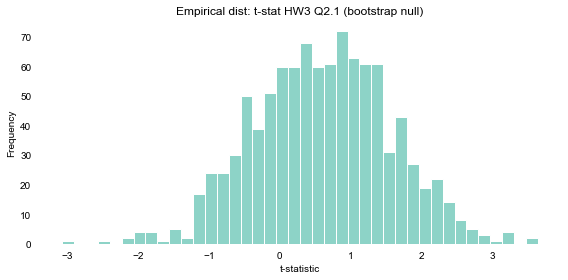

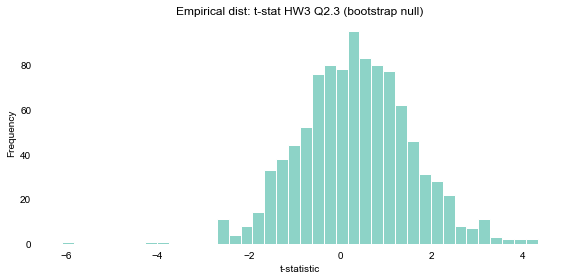

In [8]:
#Bootstrap
B = 1000
t_q21 = np.empty(B)
t_q23 = np.empty(B)
r2_q23 = np.empty(B)

t_q21_ols = np.empty(B)
t_q23_ols = np.empty(B)
r2_q23_ols = np.empty(B)

for b in range(B):
    idx = np.random.randint(0, T-1, size=T-1)
    U_b = U[idx, :]
    e_r = U_b[:, 0]
    e_d = U_b[:, 1]

    rt_star = np.empty(T)
    dy_star = np.empty(T)

    dy_star[0] = dy[0]
    rt_star[0] = rt[0]

    for t in range(1, T):
        rt_star[t] = alpha_r + e_r[t-1]
        dy_star[t] = a_dy + phi * dy_star[t-1] + e_d[t-1]

    t_q21[b] = HW3_Q21(rt_star, dy_star)
    t_q23[b], r2_q23[b] = HW3_Q23(rt_star, dy_star)
    t_q21_ols[b] = HW3_Q21_OLS(rt_star, dy_star)
    t_q23_ols[b], r2_q23_ols[b] = HW3_Q23_OLS(rt_star, dy_star)

# First histogram
fig, ax = plt.subplots(figsize=(8, 4), facecolor="white")
ax.set_facecolor("white")

ax.hist(t_q21, bins=40)
ax.set_xlabel("t-statistic")
ax.set_ylabel("Frequency")
ax.set_title("Empirical dist: t-stat HW3 Q2.1 (bootstrap null)")
ax.tick_params(axis="both", colors="black")
ax.xaxis.label.set_color("black")
ax.yaxis.label.set_color("black")
ax.title.set_color("black")

fig.tight_layout()
plt.show()

# Second histogram
fig, ax = plt.subplots(figsize=(8, 4), facecolor="white")
ax.set_facecolor("white")

ax.hist(t_q23, bins=40)
ax.set_xlabel("t-statistic")
ax.set_ylabel("Frequency")
ax.set_title("Empirical dist: t-stat HW3 Q2.3 (bootstrap null)")
ax.tick_params(axis="both", colors="black")
ax.xaxis.label.set_color("black")
ax.yaxis.label.set_color("black")
ax.title.set_color("black")

fig.tight_layout()
plt.show()



Do the tests have good size properties for a 5% two-sided test?
(It is actually ok to square the
t-statistics and investigate the 5% p-value for a χ2(1).) Also compute the empirical distribution of
the R2 for the regression in Question 2.3 of Homework 3. Describe what you observe. Use 1,000
replications for this bootstrap.

R2_actual: 0.018912050675709557
pval_R2: 0.243
Size (Q2.1): 0.084
Size (Q2.3): 0.11
Size HAC/HC3 (Q2.1): 0.084 | Size OLS (Q2.1): 0.089
Size HAC/HC3 (Q2.3): 0.11 | Size OLS (Q2.3): 0.54


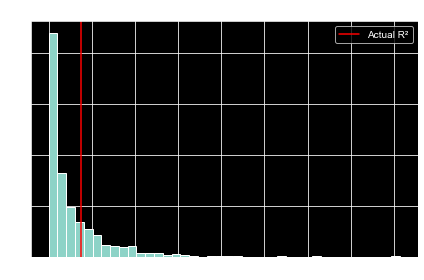

In [11]:
# --- Define R2_actual from the real (non-bootstrap) data using the same Q2.3 spec
Y3_act = pd.Series(rt).rolling(12).sum().shift(-11).to_numpy()
X3_act = sm.add_constant(dy)
mask_act = ~np.isnan(Y3_act)

fit3_act = sm.OLS(Y3_act[mask_act], X3_act[mask_act]).fit(cov_type="HAC", cov_kwds={"maxlags": 11})
R2_actual = fit3_act.rsquared

# --- Bootstrap p-value for R^2 (right-tail)
pval_R2 = np.mean(r2_q23 >= R2_actual)

print("R2_actual:", R2_actual)
print("pval_R2:", pval_R2)

chi2_95 = 3.841458820694124  # 95% quantile of chi^2(1)
size_q21 = np.mean(t_q21**2 > chi2_95)
size_q23 = np.mean(t_q23**2 > chi2_95)
size_q21_ols = np.mean(t_q21_ols**2 > chi2_95)
size_q23_ols = np.mean(t_q23_ols**2 > chi2_95)

print("Size (Q2.1):", size_q21)
print("Size (Q2.3):", size_q23)

print("Size HAC/HC3 (Q2.1):", size_q21, "| Size OLS (Q2.1):", size_q21_ols)
print("Size HAC/HC3 (Q2.3):", size_q23, "| Size OLS (Q2.3):", size_q23_ols)

fig, ax = plt.subplots()
ax.hist(r2_q23, bins=40)
ax.axvline(R2_actual, color='red', label='Actual R²')
ax.legend()
ax.set_title("Empirical dist: R² HW3 Q2.3 (bootstrap null)")
fig.tight_layout()
plt.show()


First taking a look at the plotted t-values in the two histograms we can see a wider distribution in 2.3 vs 2.1. The distributions both look normal but 2.3 has larger tails and a more pronounced center while 2.1 is more bell shaped.


Looking at the R^2 we can see that it is incredibly low showing nearly no correlation in the OLS regression. This is also supported by the p-value which is significantly higher than 0.05 and thus showing the results are not statistically significant. This observation is to be expected as under the null hypothesis of no predictablity the R^2 should be low.


For this test we reject the null if $|t|$ > 1.96 or if $|t^2| = \chi^2_{1,0.95} > 3.84$.
The function for size: np.mean(t_q21**2 > chi2_95) calculates the proportion of the test which is above the chi squared critical value. Given the results are around 0.1 for both Q2.1 and Q2.3 we can say that the test is oversized test are over-rejecting the null hypothesis. There are to many false positives in the montecarlo simulation. THe perfect number here should be around the critical value of the test of 0.05
